In [68]:
# Combine results into a csv- Cornell

import re
import pandas as pd
import numpy as np
import os

parent_folder = '/Users/gabriellebaxter/Documents/HEAL_Volunteers/cornell_rescan'
rpbm_folder = os.path.join(parent_folder,'rpbm_results')
output_file = os.path.join(parent_folder,'rpbm_results.csv')
dti_file = os.path.join(parent_folder,'dti_results.csv')
combined_file = os.path.join(parent_folder,'combined_results.csv')

files = os.listdir(rpbm_folder)
files = [s for s in files if 'WCMyofascial2' in s]
cases = [s[5:21] for s in files]
cases = list(set(cases))
cases.sort()
print(cases)

data = pd.DataFrame()
rois = ['left_masseter','right_masseter','left_temporalis','right_temporalis']

data = pd.DataFrame()
columns = ['Subject','ROI','ROI_type','a','kappa','D0','R2','RMSE']
for case in cases:
    for roi in rois:
        rpbm_txt = os.path.join(rpbm_folder,'rpbm_' + case + '_' + roi + '.txt') 
        # print(rpbm_txt)
        if os.path.exists(rpbm_txt):
            with open(rpbm_txt, "r") as f:
                text = f.read()

                # Extract the Fixed block only
                fixed_block_match = re.search(
                    r"-----\s*Fitted Results Fixed\s*-----(.*?)(?:-----\s*Fitted Results Vary\s*-----|$)",
                    text,
                    re.DOTALL | re.IGNORECASE
                )
                fixed_block = fixed_block_match.group(1) if fixed_block_match else ""

                # Extract the 'a' value from Fixed block only
                a_match = re.search(r"\ba\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                a_value = float(a_match.group(1)) if a_match else None

                k_match = re.search(r"\bkappa\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                k_value = float(k_match.group(1)) if k_match else None

                d0_match = re.search(r"\bD0\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                d0_value = float(d0_match.group(1)) if d0_match else None

                # Extract rsquare (from Fixed block too, since rsquare belongs there)
                rsq_match = re.search(r"\brsquare\s*[:=]\s*([+-]?\d+(?:\.\d+)?)", fixed_block, re.IGNORECASE)
                rsquare_value = float(rsq_match.group(1)) if rsq_match else None

                rmse_match = re.search(r"\brmse\s*[:=]\s*([+-]?\d+(?:\.\d+)?)", fixed_block, re.IGNORECASE)
                rmse_value = float(rmse_match.group(1)) if rmse_match else None
                
                # just rpbm
                if 'triggerpoints' in rpbm_folder:
                    roi_type = 'triggerpoint'
                else:
                    roi_type = 'WholeROI'
                temp_data = [case,roi,roi_type,a_value,k_value,d0_value,rsquare_value,rmse_value]

                temp_df = pd.DataFrame([temp_data],columns=columns)
                data = pd.concat([data, temp_df], ignore_index=True)
print(data)
data.to_csv(output_file,index=False)

# stitch together with dti results csv
dti = pd.read_csv(dti_file)

df = pd.merge(data, dti, on=['Subject','ROI'])
folder_name = os.path.basename(parent_folder.rstrip('/'))
df['center'] = folder_name
df.insert(0, 'center', df.pop('center'))
df.to_csv(combined_file,index=False)

['WCMyofascial2012', 'WCMyofascial2013', 'WCMyofascial2014', 'WCMyofascial2015', 'WCMyofascial2016', 'WCMyofascial2017', 'WCMyofascial2018', 'WCMyofascial2019', 'WCMyofascial2020', 'WCMyofascial2021', 'WCMyofascial2033', 'WCMyofascial2034', 'WCMyofascial2036', 'WCMyofascial2037', 'WCMyofascial2038', 'WCMyofascial2039', 'WCMyofascial2040', 'WCMyofascial2041', 'WCMyofascial2043', 'WCMyofascial2044', 'WCMyofascial2056', 'WCMyofascial2058', 'WCMyofascial2059', 'WCMyofascial2060', 'WCMyofascial2061', 'WCMyofascial2063', 'WCMyofascial2064', 'WCMyofascial2066', 'WCMyofascial2076', 'WCMyofascial2078', 'WCMyofascial2080', 'WCMyofascial2082', 'WCMyofascial2083', 'WCMyofascial2084', 'WCMyofascial2085', 'WCMyofascial2086', 'WCMyofascial2087', 'WCMyofascial2089']
              Subject               ROI  ROI_type       a  kappa     D0  \
0    WCMyofascial2012     left_masseter  WholeROI  34.583  0.085  1.694   
1    WCMyofascial2012    right_masseter  WholeROI  29.290  0.105  1.736   
2    WCMyofasc

In [73]:
# Combine results into a csv- NYU

import re
import pandas as pd
import numpy as np
import os

parent_folder = '/Users/gabriellebaxter/Documents/HEAL_Volunteers/nyu'
rpbm_folder = os.path.join(parent_folder,'rpbm_results_triggerpoints')
output_file = os.path.join(parent_folder,'rpbm_results_triggerpoints.csv')
dti_file = os.path.join(parent_folder,'dti_results_triggerpoints.csv')
combined_file = os.path.join(parent_folder,'combined_results_triggerpoints.csv')

files = os.listdir(rpbm_folder)
files = [s for s in files if 'C2' in s]
cases = [s[5:11] for s in files]
cases = list(set(cases))
cases.sort()
print(cases)

data = pd.DataFrame()
rois = ['left_masseter','right_masseter','left_temporalis','right_temporalis']

data = pd.DataFrame()
columns = ['Subject','ROI','ROI_type','a','kappa','D0','R2','RMSE']
for case in cases:
    for roi in rois:
        rpbm_txt = os.path.join(rpbm_folder,'rpbm_' + case + '_' + roi + '.txt') 
        # print(rpbm_txt)
        if os.path.exists(rpbm_txt):
            with open(rpbm_txt, "r") as f:
                text = f.read()

                # Extract the Fixed block only
                fixed_block_match = re.search(
                    r"-----\s*Fitted Results Fixed\s*-----(.*?)(?:-----\s*Fitted Results Vary\s*-----|$)",
                    text,
                    re.DOTALL | re.IGNORECASE
                )
                fixed_block = fixed_block_match.group(1) if fixed_block_match else ""

                # Extract the 'a' value from Fixed block only
                a_match = re.search(r"\ba\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                a_value = float(a_match.group(1)) if a_match else None

                k_match = re.search(r"\bkappa\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                k_value = float(k_match.group(1)) if k_match else None

                d0_match = re.search(r"\bD0\s*=\s*([+-]?\d+(?:\.\d+)?)", fixed_block)
                d0_value = float(d0_match.group(1)) if d0_match else None

                # Extract rsquare (from Fixed block too, since rsquare belongs there)
                rsq_match = re.search(r"\brsquare\s*[:=]\s*([+-]?\d+(?:\.\d+)?)", fixed_block, re.IGNORECASE)
                rsquare_value = float(rsq_match.group(1)) if rsq_match else None

                rmse_match = re.search(r"\brmse\s*[:=]\s*([+-]?\d+(?:\.\d+)?)", fixed_block, re.IGNORECASE)
                rmse_value = float(rmse_match.group(1)) if rmse_match else None
                
                # just rpbm
                if 'triggerpoints' in rpbm_folder:
                    roi_type = 'triggerpoint'
                else:
                    roi_type = 'WholeROI'
                temp_data = [case,roi,roi_type,a_value,k_value,d0_value,rsquare_value,rmse_value]

                temp_df = pd.DataFrame([temp_data],columns=columns)
                data = pd.concat([data, temp_df], ignore_index=True)
print(data)
data.to_csv(output_file,index=False)

# stitch together with dti results csv
dti = pd.read_csv(dti_file)

df = pd.merge(data, dti, on=['Subject','ROI'])
folder_name = os.path.basename(parent_folder.rstrip('/'))
df['center'] = folder_name
df.insert(0, 'center', df.pop('center'))

matching_codes = pd.read_csv('/Users/gabriellebaxter/Documents/code/HEAL_scripts/rescan_rpbm/matching_codes.csv')
df = df.rename(columns={'Subject': 'NYU_ID'})
wcmids = []
for index,row in df.iterrows():
    nyuid = row['NYU_ID']
    matched_df = matching_codes[matching_codes['NYU_ID'] == nyuid]
    wcmid = matched_df['WCM_ID'].values[0]
    wcmid = 'WCMyofascial' + str(matched_df['WCM_ID'].values[0])
    wcmids.append(wcmid)
df['Subject'] = wcmids
df.insert(1, 'Subject', df.pop('Subject'))

df.to_csv(combined_file,index=False)

['C2_006', 'C2_008', 'C2_010', 'C2_011', 'C2_013', 'C2_014', 'C2_017', 'C2_019', 'C2_020', 'C2_023', 'C2_029']
   Subject               ROI      ROI_type       a        kappa     D0  \
0   C2_006   left_temporalis  triggerpoint  30.705        0.104  1.701   
1   C2_006  right_temporalis  triggerpoint  24.004        0.097  1.743   
2   C2_008     left_masseter  triggerpoint  48.157        0.030  0.949   
3   C2_008    right_masseter  triggerpoint  37.350        0.045  1.367   
4   C2_010     left_masseter  triggerpoint  46.136        0.025  1.426   
5   C2_010    right_masseter  triggerpoint   1.803        1.948  1.377   
6   C2_010   left_temporalis  triggerpoint  37.705        0.067  1.789   
7   C2_010  right_temporalis  triggerpoint  43.772        0.051  1.761   
8   C2_011     left_masseter  triggerpoint  36.011        0.043  1.607   
9   C2_011    right_masseter  triggerpoint  56.049        0.020  1.467   
10  C2_011  right_temporalis  triggerpoint  45.811        0.048  1.757   
1

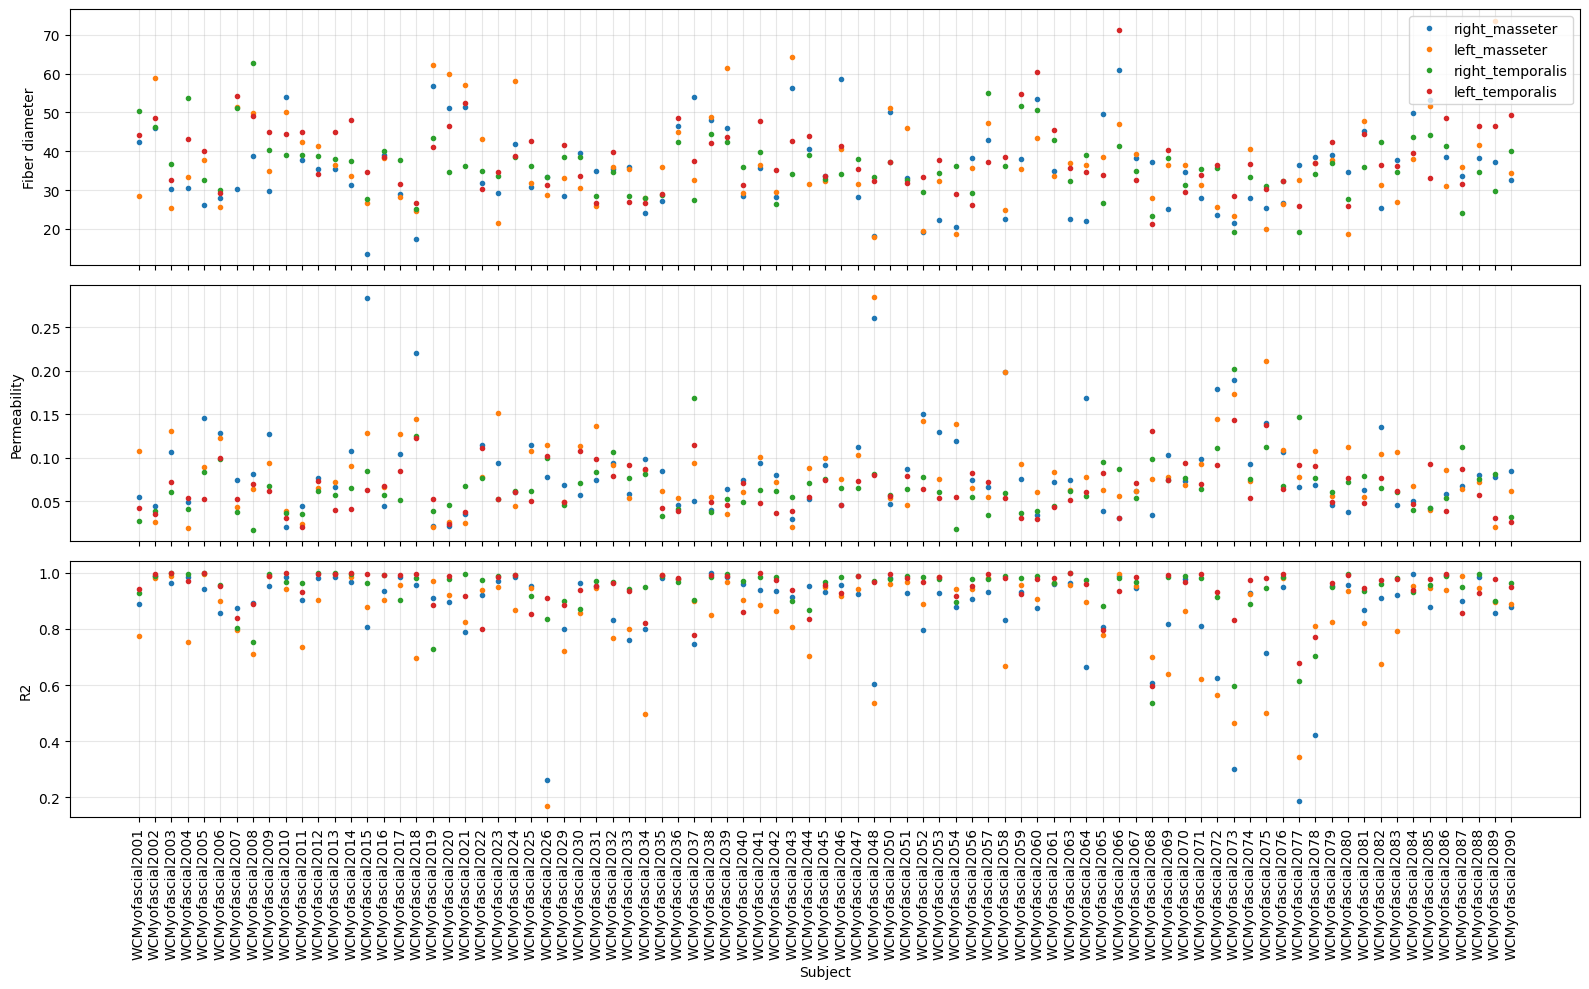

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = '/Users/gabriellebaxter/Documents/HEAL_Volunteers/cornell/combined_results.csv'
df = pd.read_csv(results_csv)

roi_names = ["right_masseter","left_masseter","right_temporalis","left_temporalis"]
params = ['a','kappa','R2']
ylabels = {'a':'Fiber diameter','kappa':'Permeability','R2':'R2'}

fig, axes = plt.subplots(3,1,figsize=(16,10),sharex=True)

for ax, param in zip(axes, params):
    for roi_name in roi_names:
        subset = df[df['ROI'] == roi_name]
        ax.plot(subset['Subject'].values, subset[param].values, '.', label=roi_name)
    ax.set_ylabel(ylabels[param])
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[-1].set_xlabel('Subject')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

['RD_median_0022ms', 'AD_median_0022ms', 'FA_median_0022ms', 'RD_median_0042ms', 'AD_median_0042ms', 'FA_median_0042ms', 'RD_median_0081ms', 'AD_median_0081ms', 'FA_median_0081ms', 'RD_median_0156ms', 'AD_median_0156ms', 'FA_median_0156ms', 'RD_median_0300ms', 'AD_median_0300ms', 'FA_median_0300ms']


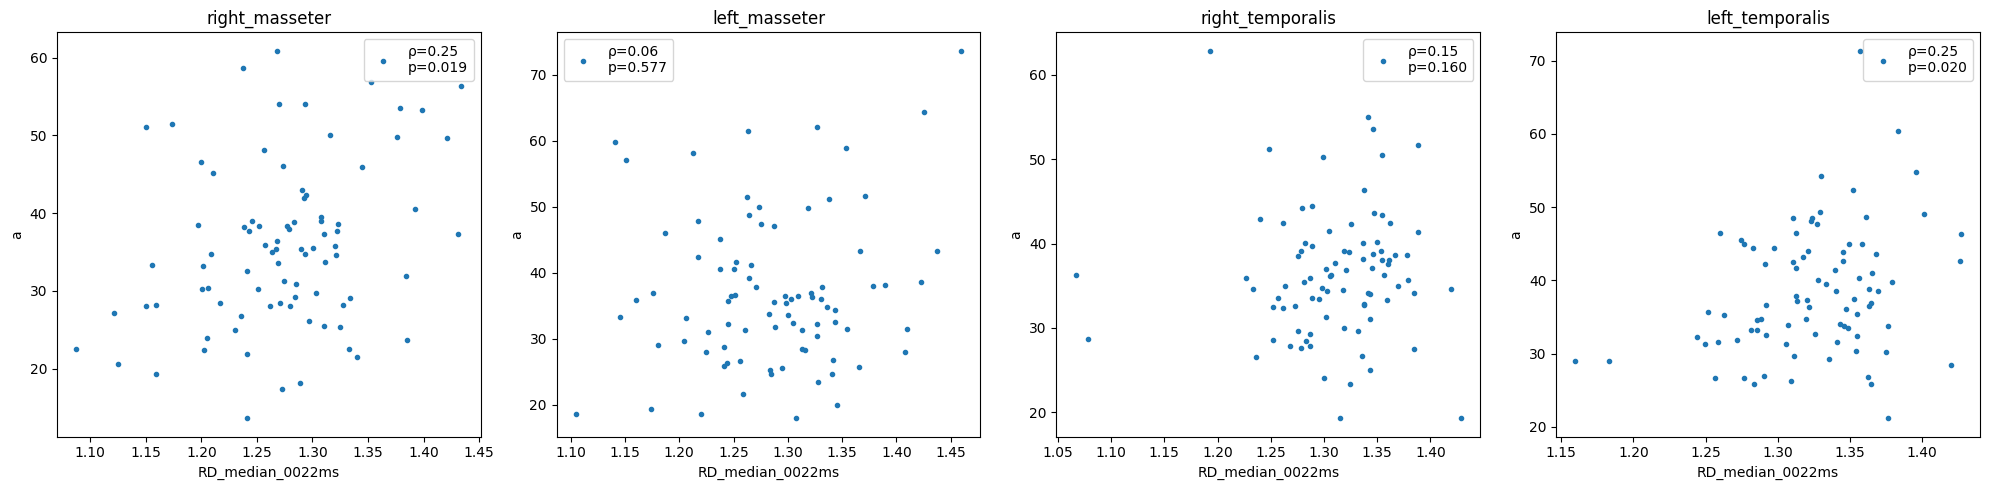

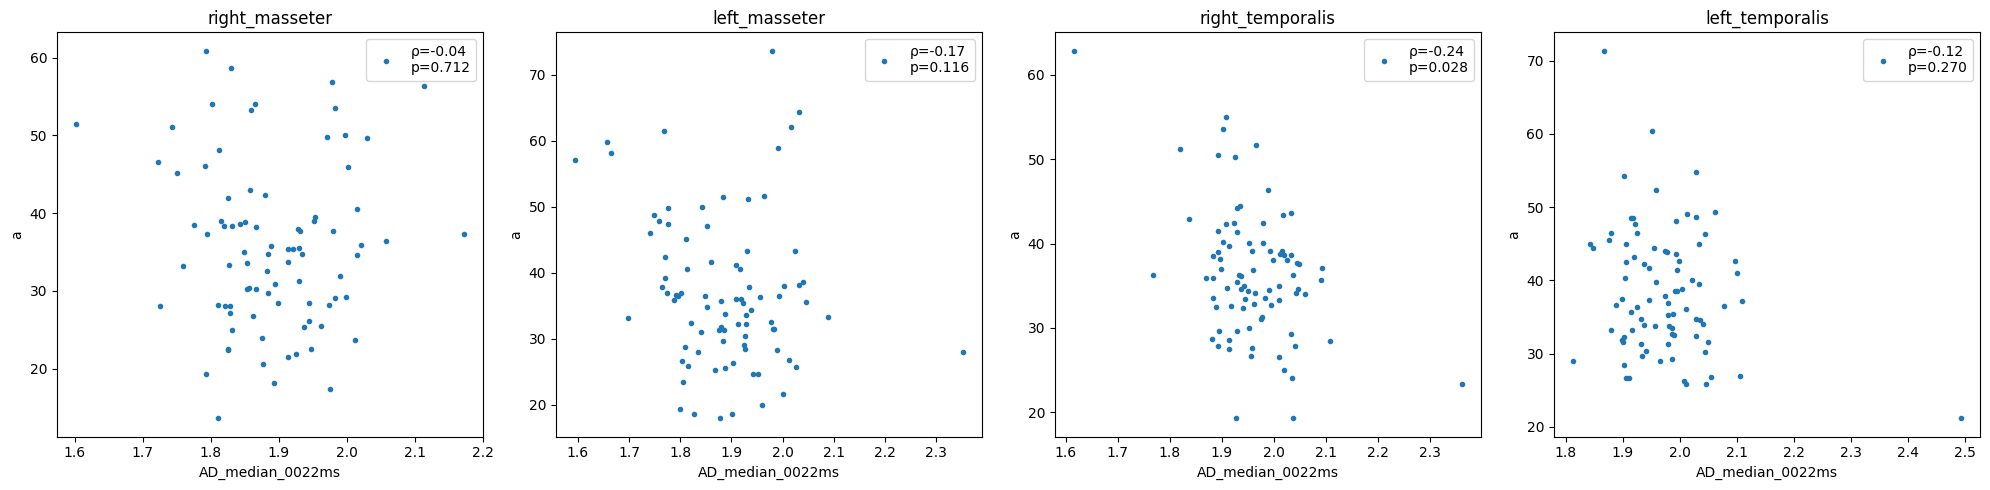

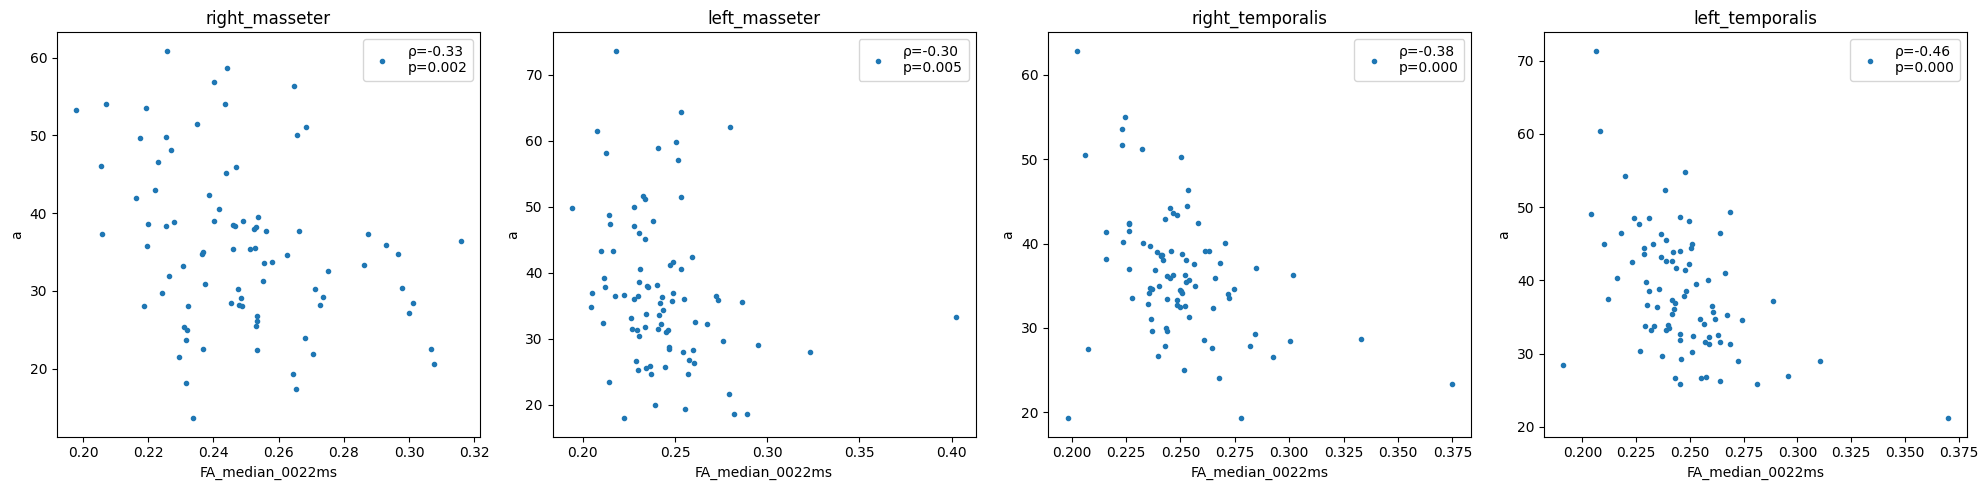

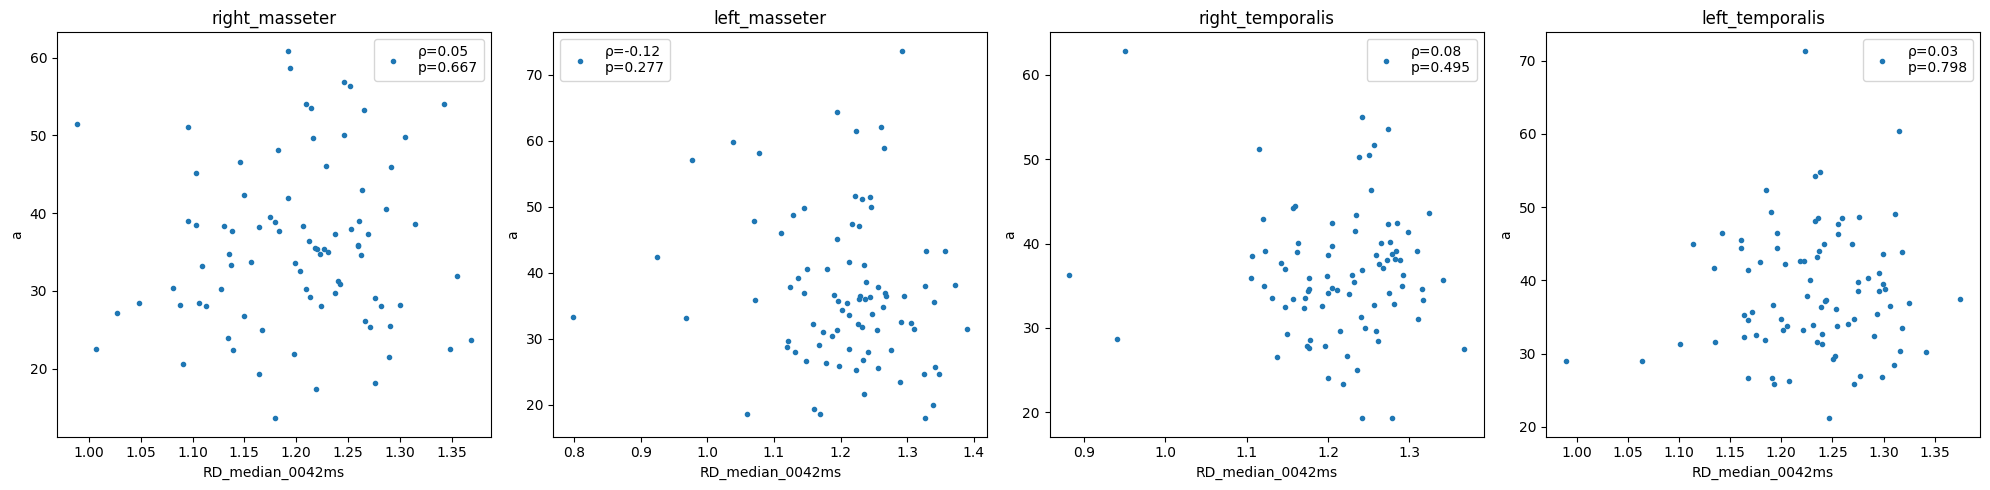

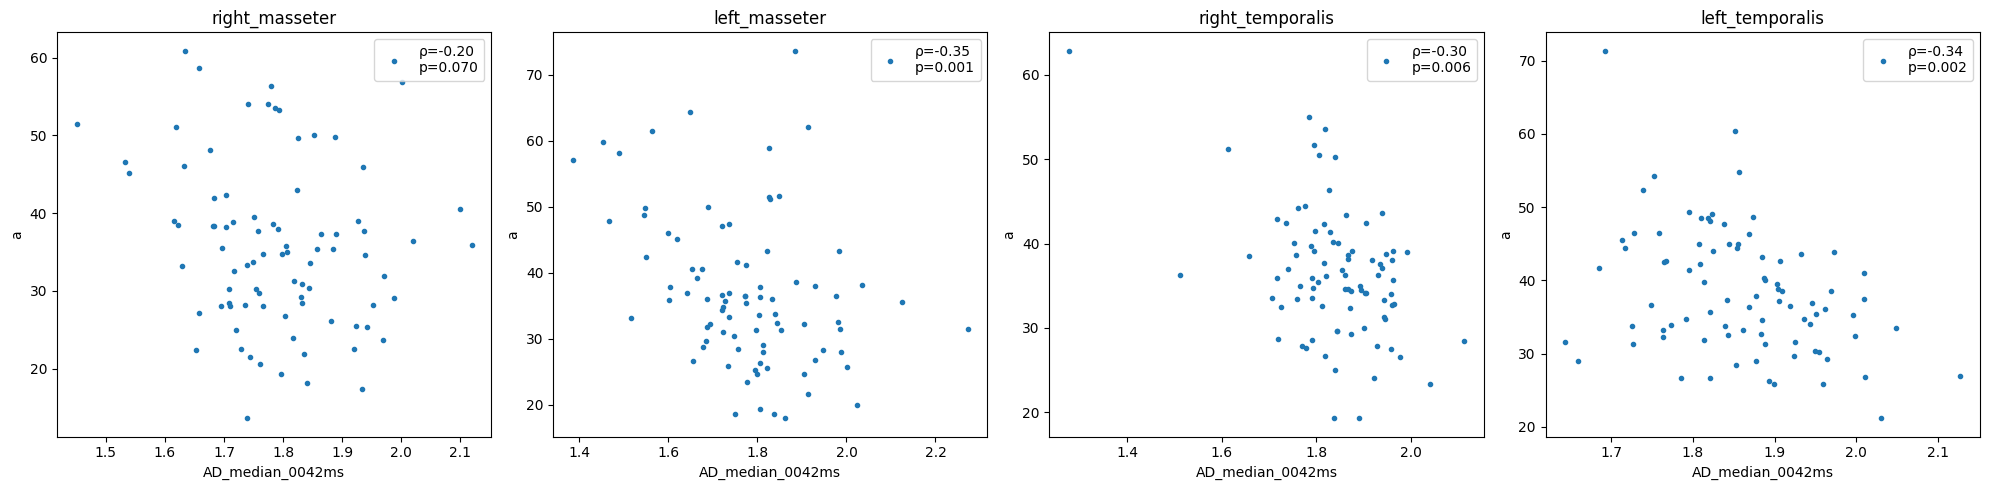

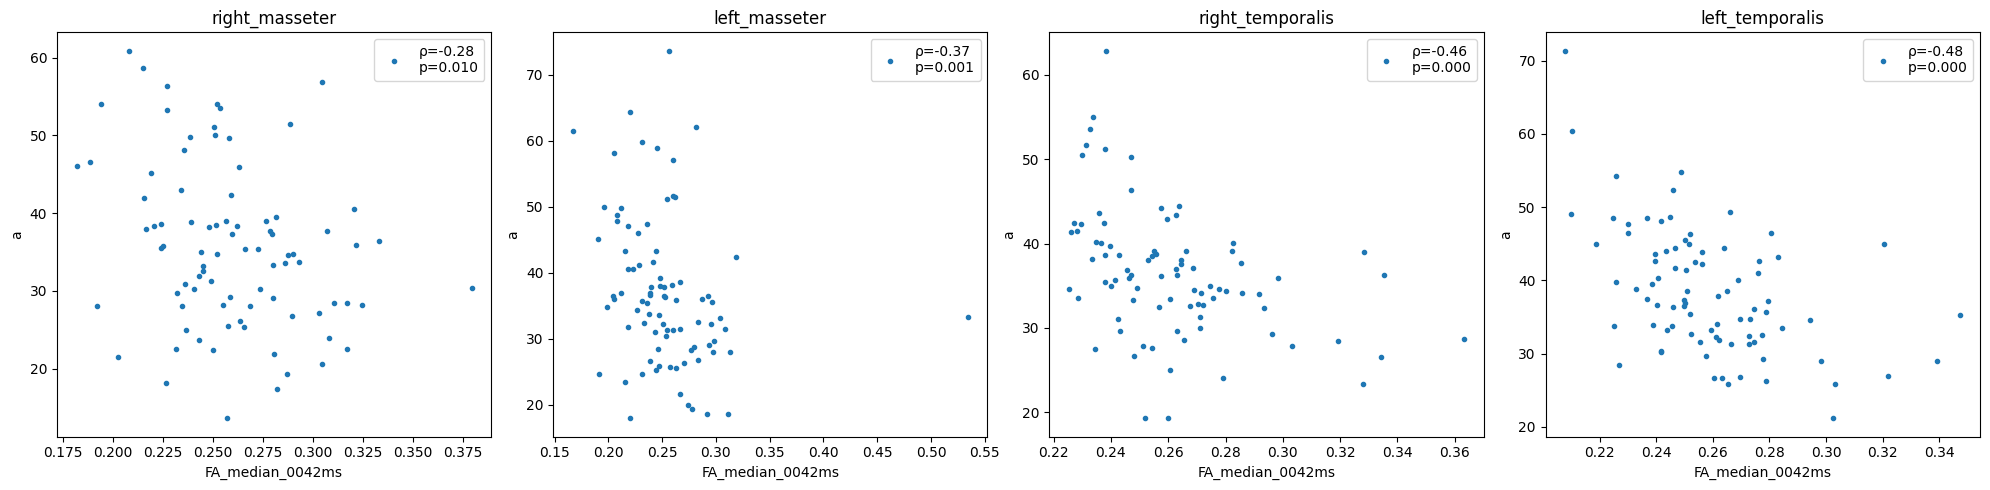

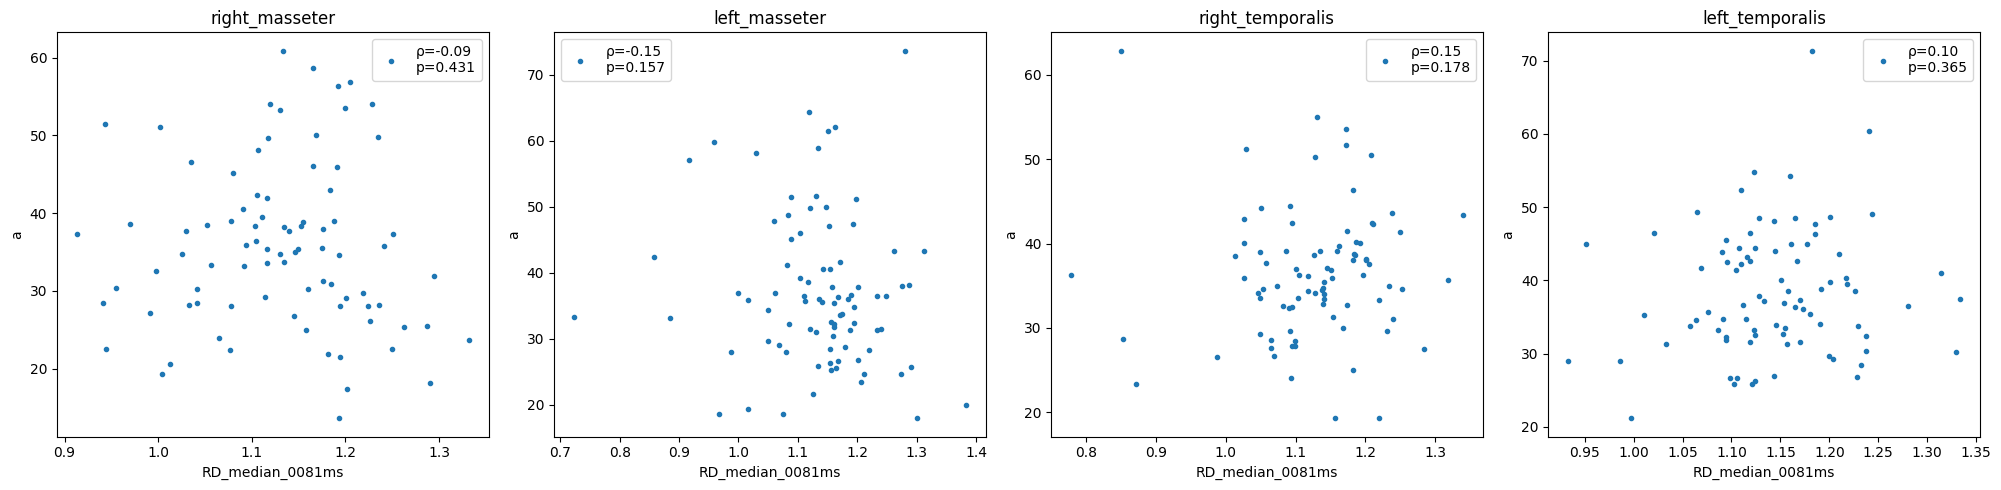

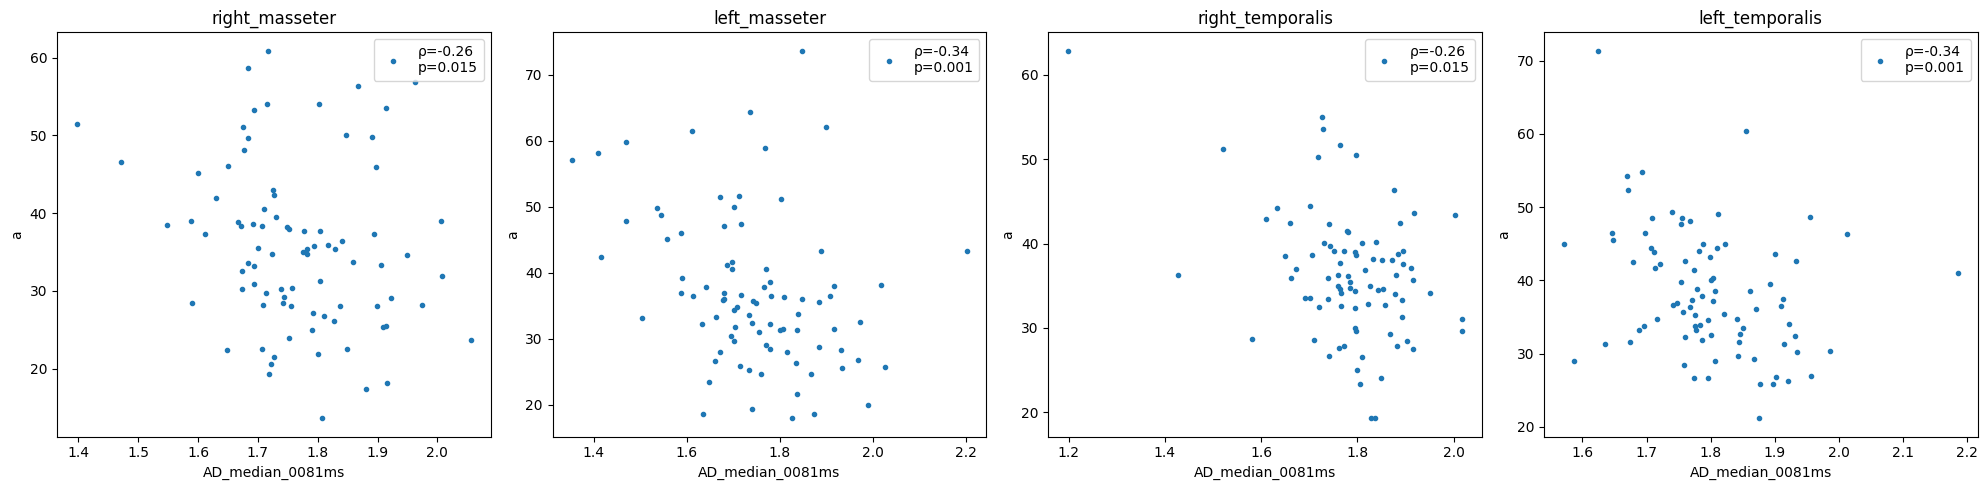

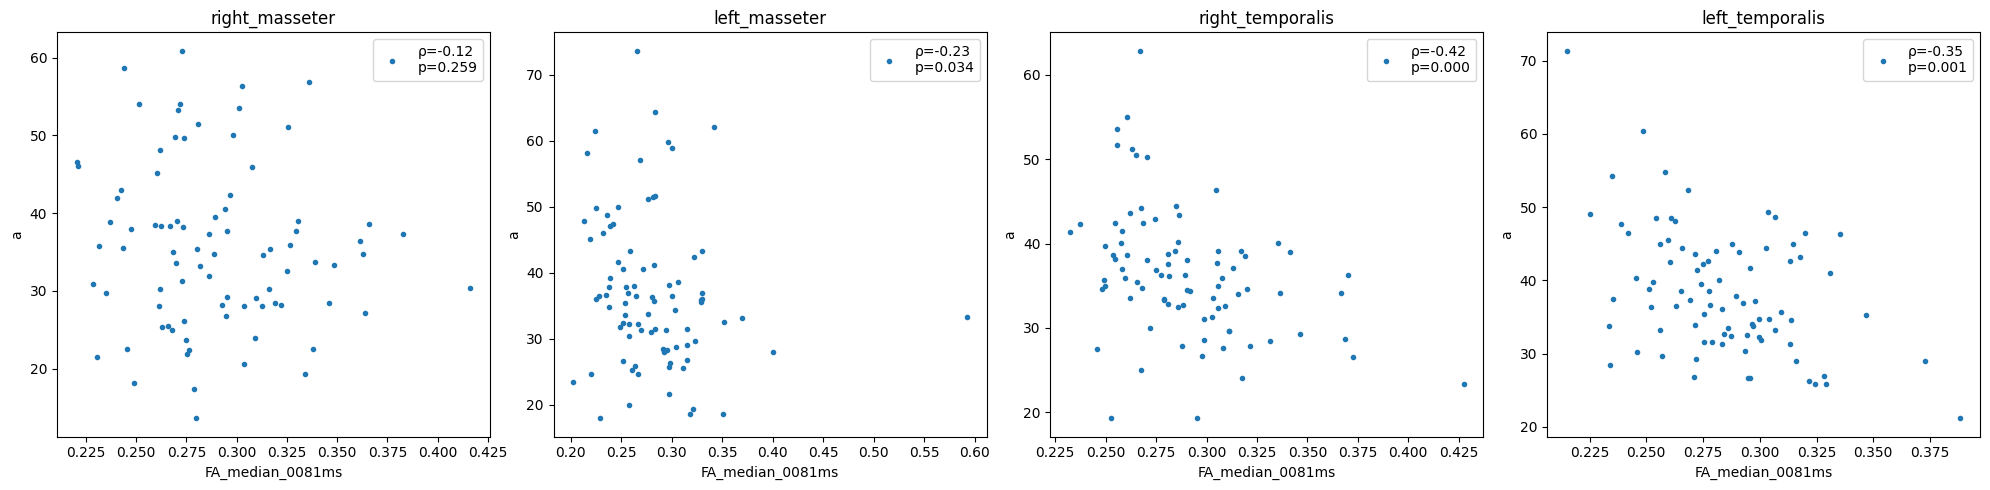

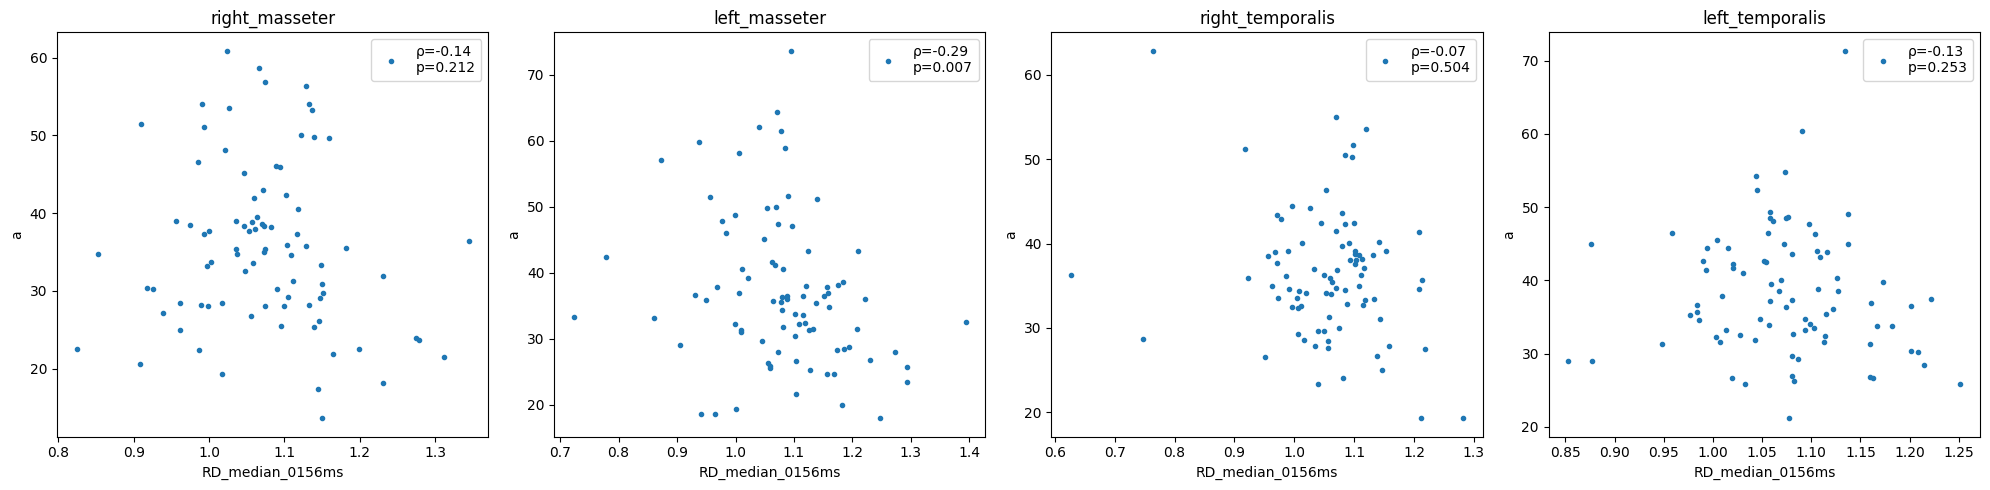

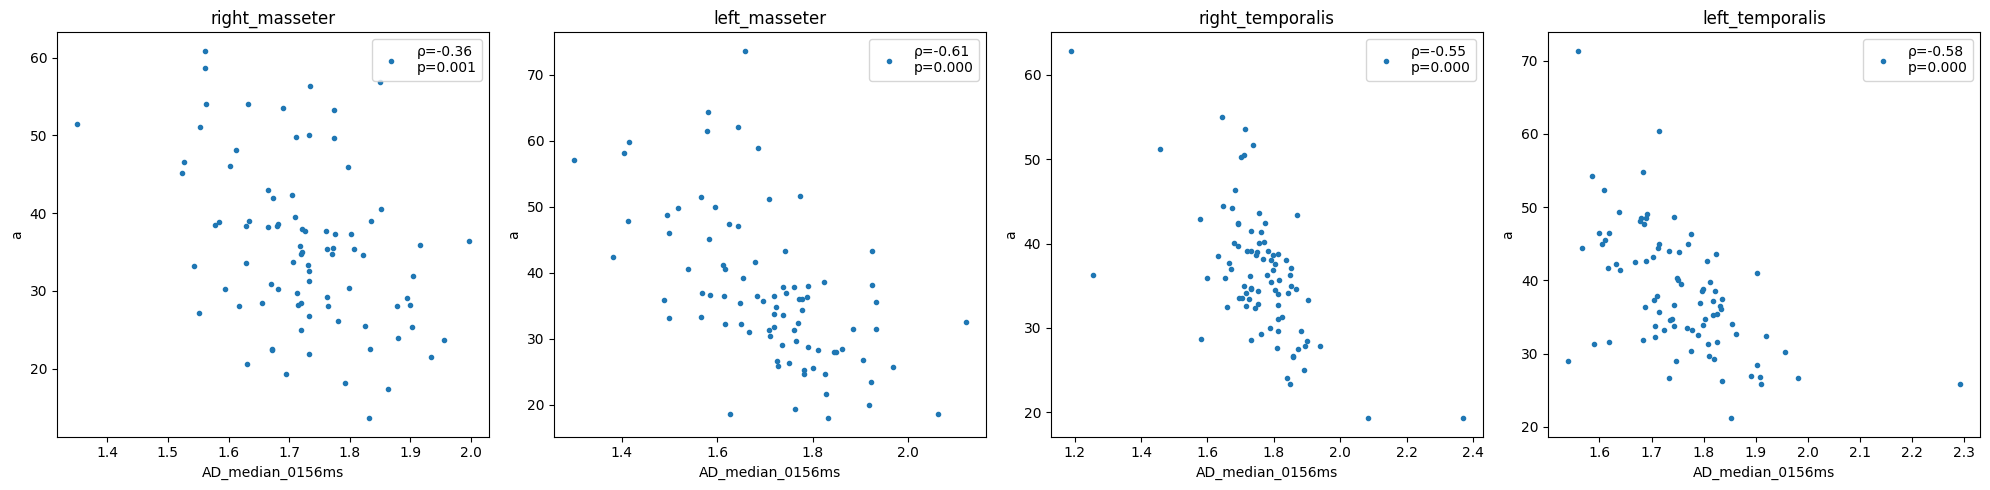

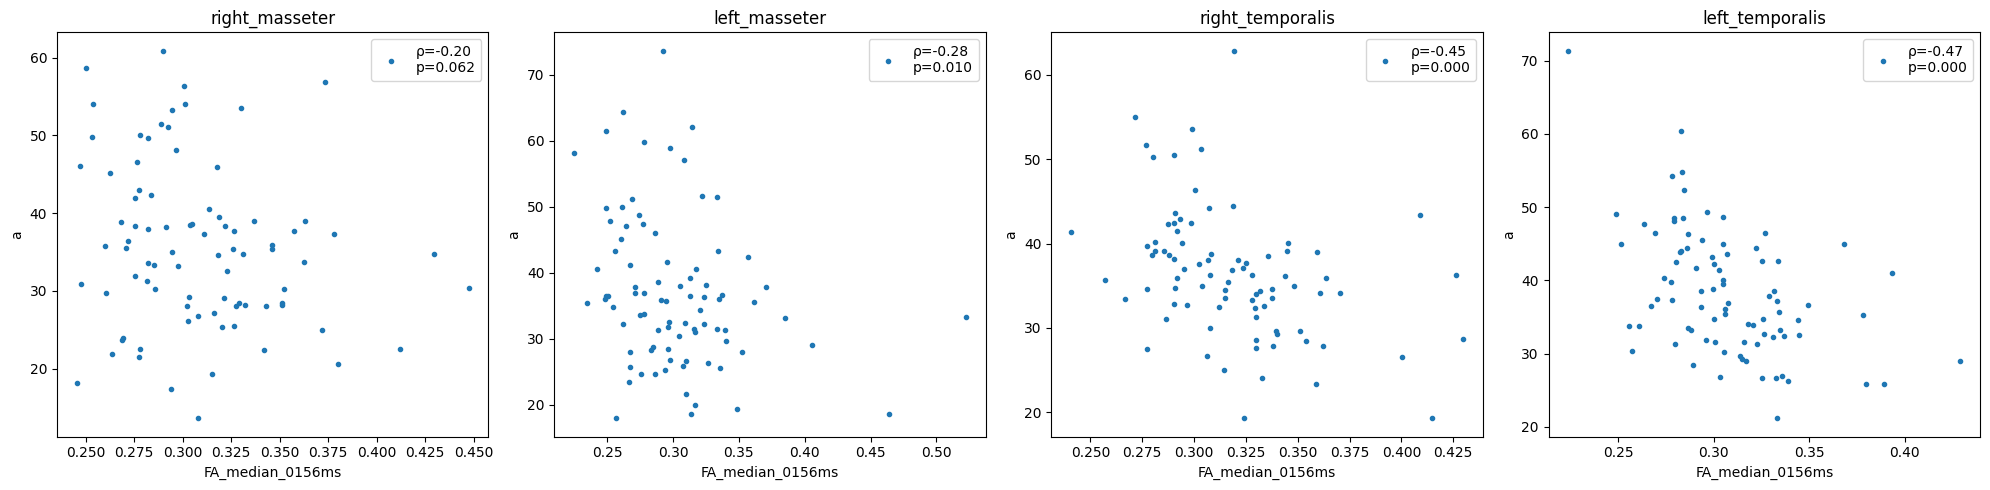

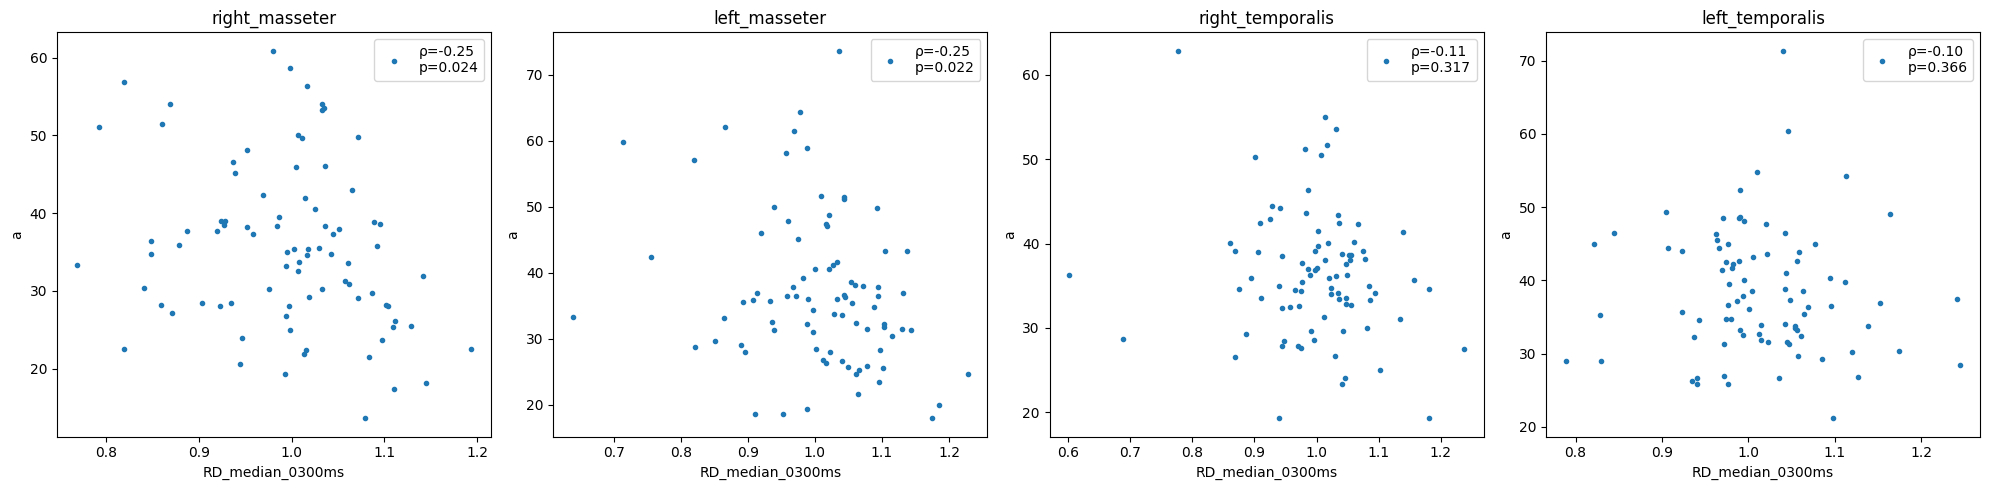

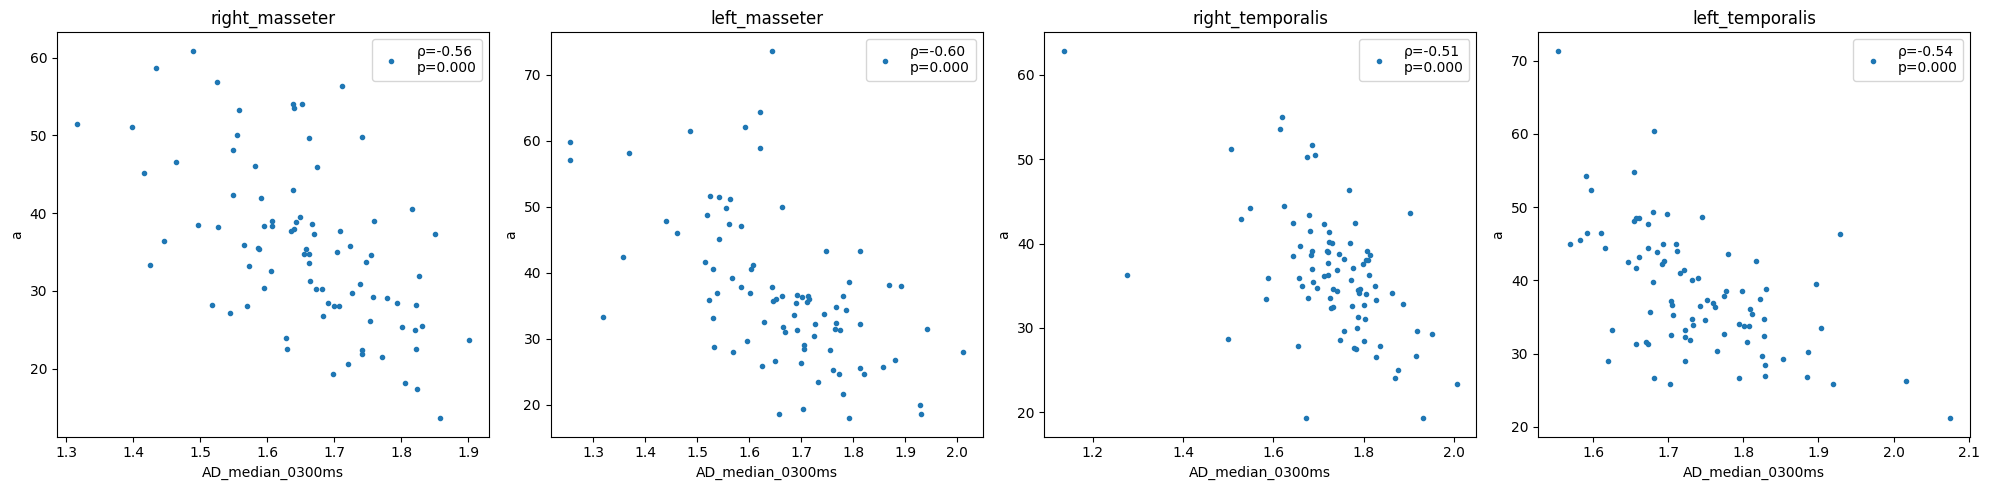

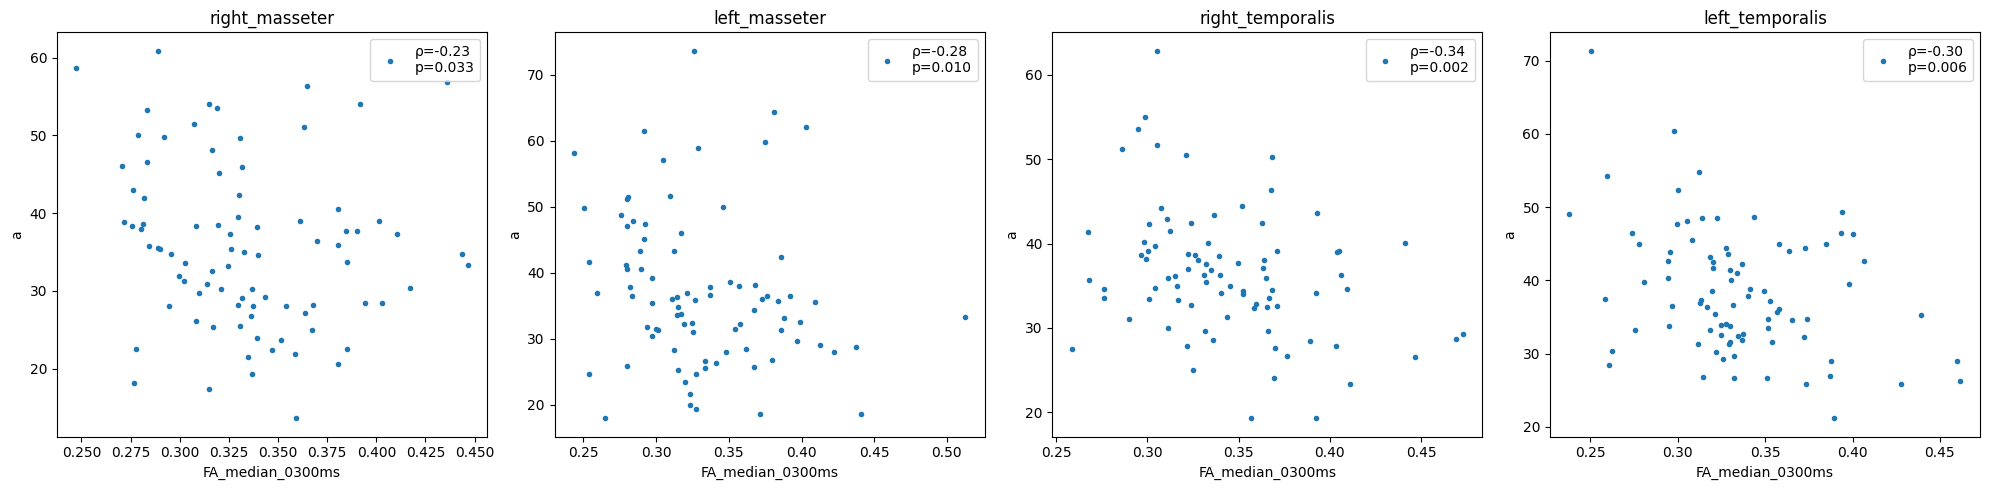

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

results_csv = '/Users/gabriellebaxter/Documents/HEAL_Volunteers/cornell/combined_results.csv'
df = pd.read_csv(results_csv)

diffusion_times = ['0022ms','0042ms','0081ms','0156ms','0300ms']
variables = [s for s in df.columns if 'median' in s]
print(variables)

param = 'a'

for var in variables:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
    for i, roi_name in enumerate(roi_names):
        temp_df = df[df['ROI'] == roi_name]

        x = temp_df[var].values
        y = temp_df[param].values

        # drop NaNs just in case
        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        if len(x) > 1:
            r, p = spearmanr(x, y)
        else:
            r = np.nan

        axes[i].plot(x, y, '.', label=f'ρ={r:.2f}\np={p:.3f}')

        axes[i].set_xlabel(var)
        axes[i].set_ylabel(param)
        axes[i].set_title(roi_name)
        axes[i].legend()

    plt.tight_layout()
    plt.show()